### Exercício 3.1

Utilizando como base os códigos apresentados anteriormente, crie um novo Notebook que seja uma demonstração (demo) de como obter o valor total de um conjunto de moedas em uma imagem. O Notebook deve conter uma breve descrição do problema e deve explicar passo a passo as etapas e códigos utilizados para chegar ao resultado final. Tente descrever e exemplificar cada etapa, indicando qual o seu objetivo, explicando os processamentos aplicados, as funções utilizadas e os parâmetros escolhidos. Ao final do Notebook, apresente links para referências úteis no aprofundamento dos tópicos abordados. Você também pode linkar referências interessantes ao longo do Notebook, à medida que apresenta as etapas e os conceitos relacionados.

Não se esqueça de enviar o Notebook da demo juntamente com a entrega deste Notebook!

# Demonstração: Contagem e Valorização de Moedas com Visão Computacional

## Descrição do Problema
O objetivo deste *notebook* é demonstrar como utilizar técnicas clássicas de processamento de imagens e visão computacional para identificar, contar e somar o valor de um conjunto de moedas em uma imagem. 

Para resolver este problema, passaremos pelas seguintes etapas:
1. **Aquisição e Pré-processamento:** Leitura da imagem e conversão para escala de cinza.
2. **Segmentação:** Binarização da imagem utilizando o método de Otsu para separar o plano de fundo dos objetos de interesse (moedas).
3. **Pós-processamento (Morfologia Matemática):** Aplicação de operações morfológicas (Fechamento e Abertura) para remover ruídos e imperfeições na segmentação.
4. **Extração de Características:** Identificação de componentes conexos para individualizar cada moeda e calcular sua respectiva área (em pixels).
5. **Classificação e Contagem:** Classificação do valor de cada moeda com base na sua área e cálculo do valor total.

In [8]:
# Importando as bibliotecas que serão utilizadas
import os

import cv2
import matplotlib.image as mpimg
import matplotlib.pyplot as plt
import numpy as np
import requests
from PIL import Image

In [11]:
def download_image(url:str) -> str:
    filename = os.path.basename(url)

    if os.path.exists(filename):
        return filename

    response = requests.get(url)

    with open(filename, mode="wb") as file:
        file.write(response.content)

    return filename

url_base = r"https://raw.githubusercontent.com/UNICAMP-EA979/EA979-Recursos/main/imgs/{value}.jpg"
values = [75, 80, 95]

filenames = []

for value in values:
    url = url_base.format(value=value)
    filename = download_image(url)
    filenames.append(filename)

## Passo 1: Leitura e Conversão para Escala de Cinza
O primeiro passo no processamento é carregar a imagem e convertê-la para escala de cinza. Isso simplifica a imagem, reduzindo a dimensionalidade (de 3 canais RGB para apenas 1 canal de intensidade), o que é ideal para a etapa de limiarização (thresholding).

A conversão segue a fórmula clássica de luminosidade:
$Y = 0.3 \cdot R + 0.59 \cdot G + 0.11 \cdot B$

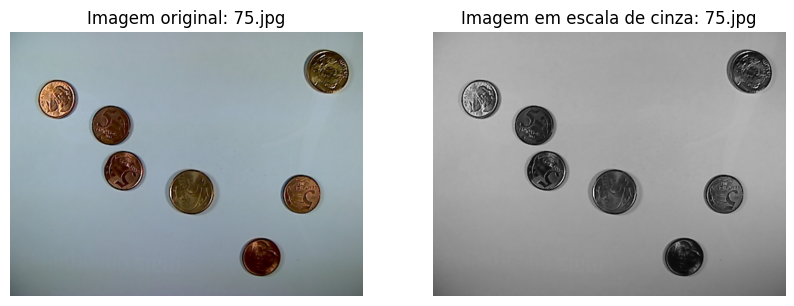

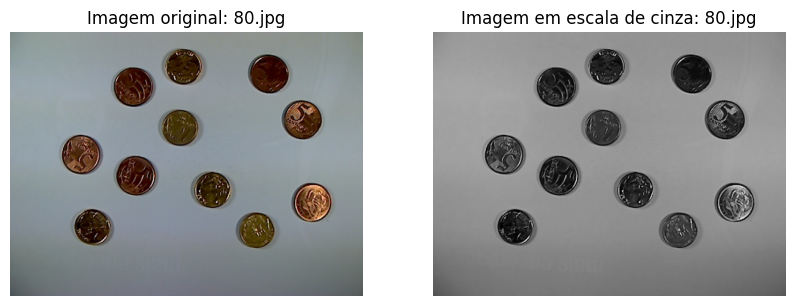

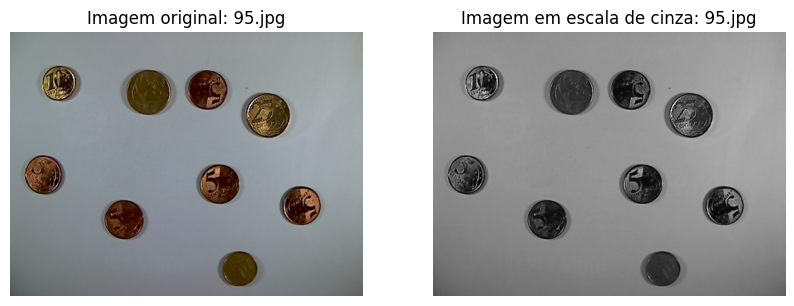

In [ ]:
# Carregar as imagens usando:
for current_file in filenames:
    img = mpimg.imread(current_file).astype('uint8')

    img_gray = np.uint8(0.3 * img[:,:,0] + 0.59 * img[:,:,1] + 0.11 * img[:,:,2])

    plt.figure(figsize=(10, 5))
    
    plt.subplot(1, 2, 1)
    plt.imshow(img)
    plt.title(f"Imagem original: {current_file}")
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.imshow(img_gray, cmap='gray')
    plt.title(f"Imagem em escala de cinza: {current_file}")
    plt.axis('off')
    
    plt.show()

## Passo 2 e 3: Segmentação e Operações Morfológicas
Para separar as moedas do fundo, utilizamos o **Método de Otsu**, que encontra automaticamente o melhor valor de limiar (threshold) para binarizar a imagem. 

Após a binarização, aplicamos **Morfologia Matemática** para corrigir imperfeições:
* **Fechamento (Closing):** Dilatação seguida de erosão. Útil para preencher pequenos buracos dentro das moedas.
* **Abertura (Opening):** Erosão seguida de dilatação. Útil para remover ruídos externos e desconectar objetos que possam estar levemente sobrepostos.

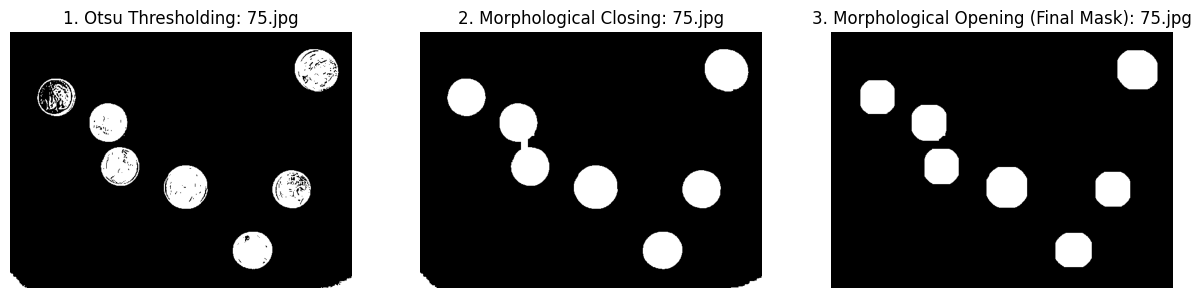

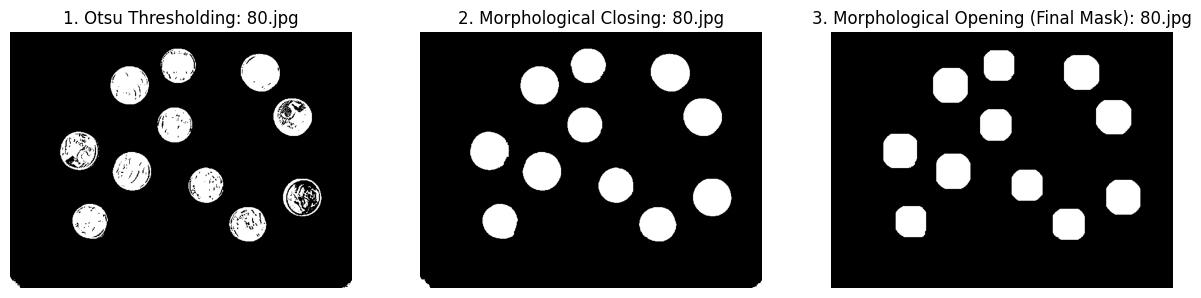

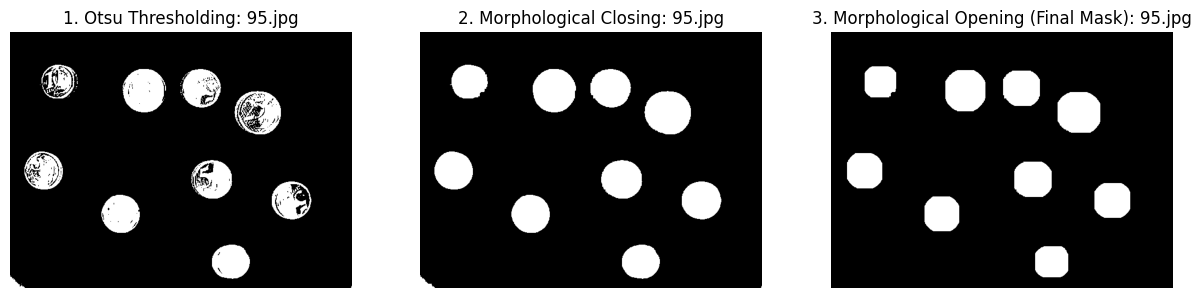

In [33]:
def segment_and_postprocess(image_gray, kernel_close_size, kernel_open_size, current_file):
    # Aplicar limiarização de Otsu. Invertemos a imagem (255 - imagem_em_tons) porque
    # queremos que as moedas sejam brancas (255) e o fundo preto (0).
    _, binary_img = cv2.threshold(255 - image_gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    
    # Defina os elementos estruturais (núcleos)
    kernel_cl = np.ones((kernel_close_size, kernel_close_size), np.uint8) 
    kernel_op = np.ones((kernel_open_size, kernel_open_size), np.uint8)

    # Aplicar fechamento morfologico para preencher orificios internos
    img_closed = cv2.morphologyEx(binary_img, cv2.MORPH_CLOSE, kernel_cl, iterations=1) 
    
    # Aplicar abertura morfologica para remover ruido externo
    img_opened = cv2.morphologyEx(img_closed, cv2.MORPH_OPEN, kernel_op, iterations=1)

    # Trace o passo intermediario
    plt.figure(figsize=(15, 5))
    plt.subplot(1, 3, 1)
    plt.imshow(binary_img, cmap='gray')
    plt.title(f"1. Otsu Thresholding: {current_file}")
    plt.axis('off')
    
    plt.subplot(1, 3, 2)
    plt.imshow(img_closed, cmap='gray')
    plt.title(f"2. Morphological Closing: {current_file}")
    plt.axis('off')
    
    plt.subplot(1, 3, 3)
    plt.imshow(img_opened, cmap='gray')
    plt.title(f"3. Morphological Opening (Final Mask): {current_file}")
    plt.axis('off')
    plt.show()

    return img_opened

# Lista para armazenar as mascaras segmentadas para as proximas etapas
segmented_masks = []

for current_file in filenames:
    # Passo 1: Carregue a imagem e converta-a para escala de cinza.
    img = mpimg.imread(current_file).astype('uint8')
    img_gray = np.uint8(0.3 * img[:,:,0] + 0.59 * img[:,:,1] + 0.11 * img[:,:,2])

    # Etapas 2 e 3: Aplicar operações de segmentação e morfologicas
    # Chamamos a função aqui para que ela processe o 'img_gray' da iteração atual
    mask = segment_and_postprocess(image_gray=img_gray, kernel_close_size=15, kernel_open_size=31, current_file= current_file)
    
    # Adicione a mascara resultante a lista
    segmented_masks.append(mask)

## Passo 4: Extração de Componentes Conexos
Com a máscara binária finalizada, utilizamos a função `cv2.connectedComponentsWithStats`. Esta função é essencial pois ela rotula cada bloco de pixels brancos contíguos como um objeto distinto (uma moeda) e nos fornece estatísticas sobre ele, incluindo a sua área total em pixels e as coordenadas do seu centroide.

In [34]:
def calculate_pixels_per_label(labeled_img, num_labels):
    pixel_counts = []
    
    # Percorra cada rotulo, ignorando o 0 (fundo)
    for v in range(1, num_labels):
        # Contar pixels pertencentes ao rotulo atual
        area = (labeled_img[labeled_img == v] // v).sum()
        pixel_counts.append(int(area))
        
    return pixel_counts

# Listas para armazenar os resultados da etapa 4 para a etapa final de classificação
all_areas = []
all_centroids = []

# Itere sobre as mascaras geradas anteriormente e seus respectivos nomes de arquivo usando zip
for current_file, segmented_mask in zip(filenames, segmented_masks):
    print(f"--- Extraindo características para: {current_file} ---")

    # Extrair componentes conectados e suas estatísticas (conectividade = 4)
    num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(segmented_mask, 4)

    # Calcule a area de cada moeda.    
    list_areas = calculate_pixels_per_label(labels, num_labels)
    
    # Armazene os resultados da Etapa 5
    all_areas.append(list_areas)
    all_centroids.append(centroids)
    
    print(f"Total de objetos detectados: {len(list_areas)}")
    print(f"Área de cada objeto em pixels: {list_areas}\n")

--- Extraindo características para: 75.jpg ---
Total de objetos detectados: 7
Área de cada objeto em pixels: [4805, 3638, 3867, 3786, 5016, 3767, 3861]

--- Extraindo características para: 80.jpg ---
Total de objetos detectados: 11
Área de cada objeto em pixels: [2978, 3793, 3775, 3736, 3132, 3678, 3778, 3064, 3728, 3049, 3183]

--- Extraindo características para: 95.jpg ---
Total de objetos detectados: 9
Área de cada objeto em pixels: [3114, 4997, 4017, 5335, 3845, 4113, 3897, 3766, 3285]



## Passo 5: Classificação de Moedas e Contagem do Valor Total
Agora que sabemos a área de cada moeda, podemos classificá-las. Em nossa base de dados empírica:
* Moedas de **10 centavos** têm área menor que 3500 pixels.
* Moedas de **25 centavos** têm área maior que 4600 pixels.
* Moedas de **5 centavos** estão na faixa intermediária.

Iteramos sobre as áreas, somamos o valor total e anotamos a imagem original com os valores detectados utilizando as coordenadas dos centroides.

--- Classificação final para: 75.jpg ---


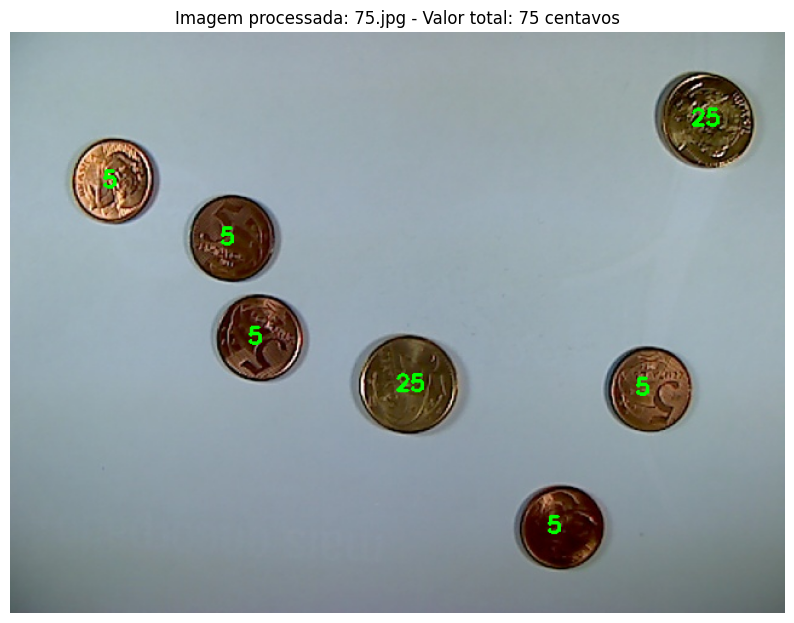

Número total de moedas: 7
Valor final calculado: 75 centavos

--- Classificação final para: 80.jpg ---


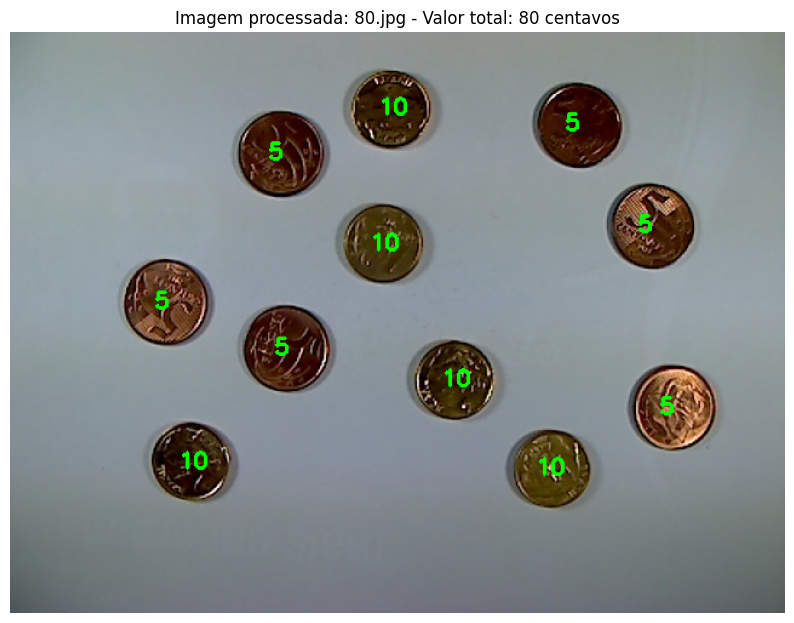

Número total de moedas: 11
Valor final calculado: 80 centavos

--- Classificação final para: 95.jpg ---


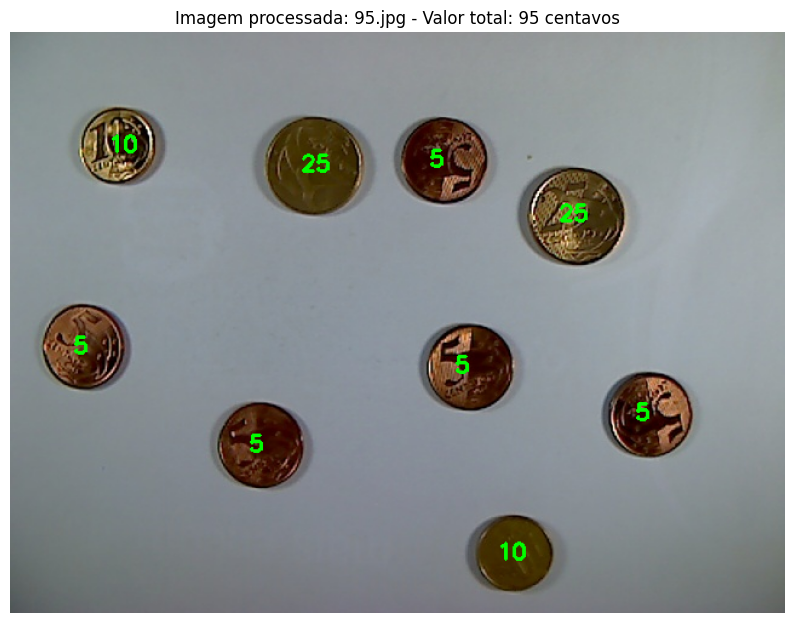

Número total de moedas: 9
Valor final calculado: 95 centavos



In [35]:
def classify_and_draw_coins(image_path, areas, centroids):
    # Carregar a imagem original com base no caminho
    img = mpimg.imread(image_path).astype('uint8')
    final_image = img.copy()
    total_value = 0

    # Itere pelas areas calculadas e seus respectivos centroides
    for index, area in enumerate(areas):
        # Coordenadas do centroide (x, y) para o posicionamento do texto. O índice + 1 ignora o fundo.
        x_coord = int(centroids[index + 1][0])
        y_coord = int(centroids[index + 1][1])

        # Regras de classificação baseadas na area do pixel
        if area < 3500:
            coin_value: int = 10
        elif area > 4600:
            coin_value: int = 25
        else:
            coin_value: int = 5
            
        total_value += coin_value
        
        # Desenhe o valor na imagem
        cv2.putText(
            img=final_image, 
            text=str(coin_value), 
            org=(x_coord - 10, y_coord + 5), # Pequeno deslocamento para melhor centralização
            fontFace=cv2.FONT_HERSHEY_SIMPLEX, 
            fontScale=0.6, 
            color=(0, 255, 0), 
            thickness=2
        )
        
    return final_image, total_value

# Percorra as listas paralelas usando zip
for current_file, list_areas, current_centroids in zip(filenames, all_areas, all_centroids):
    print(f"--- Classificação final para: {current_file} ---")
    # Processar a imagem atual usando nossa função
    annotated_image, final_value = classify_and_draw_coins(
        image_path=current_file, 
        areas=list_areas, 
        centroids=current_centroids
    )
    # Exibir o resultado final
    plt.figure(figsize=(10, 8))
    plt.imshow(annotated_image)
    plt.title(f"Imagem processada: {current_file} - Valor total: {final_value} centavos")
    plt.axis('off')
    plt.show()

    # Imprima as estatísticas da imagem atual
    print(f"Número total de moedas: {len(list_areas)}")
    print(f"Valor final calculado: {final_value} centavos\n")

## Referências Úteis

Para aprofundar meus conhecimentos nos metodos utilizados neste notebook, consultei os links abaixo:

* **OpenCV Documentação Oficial - Thresholding:** [Image Thresholding in OpenCV](https://docs.opencv.org/4.x/d7/d4d/tutorial_py_thresholding.html)
* **OpenCV Documentação Oficial - Morfologia Matemática:** [Morphological Transformations](https://docs.opencv.org/4.x/d9/d61/tutorial_py_morphological_ops.html)
* **Matplotlib Pyplot Tutorial:** [Pyplot tutorial](https://matplotlib.org/stable/tutorials/introductory/pyplot.html)